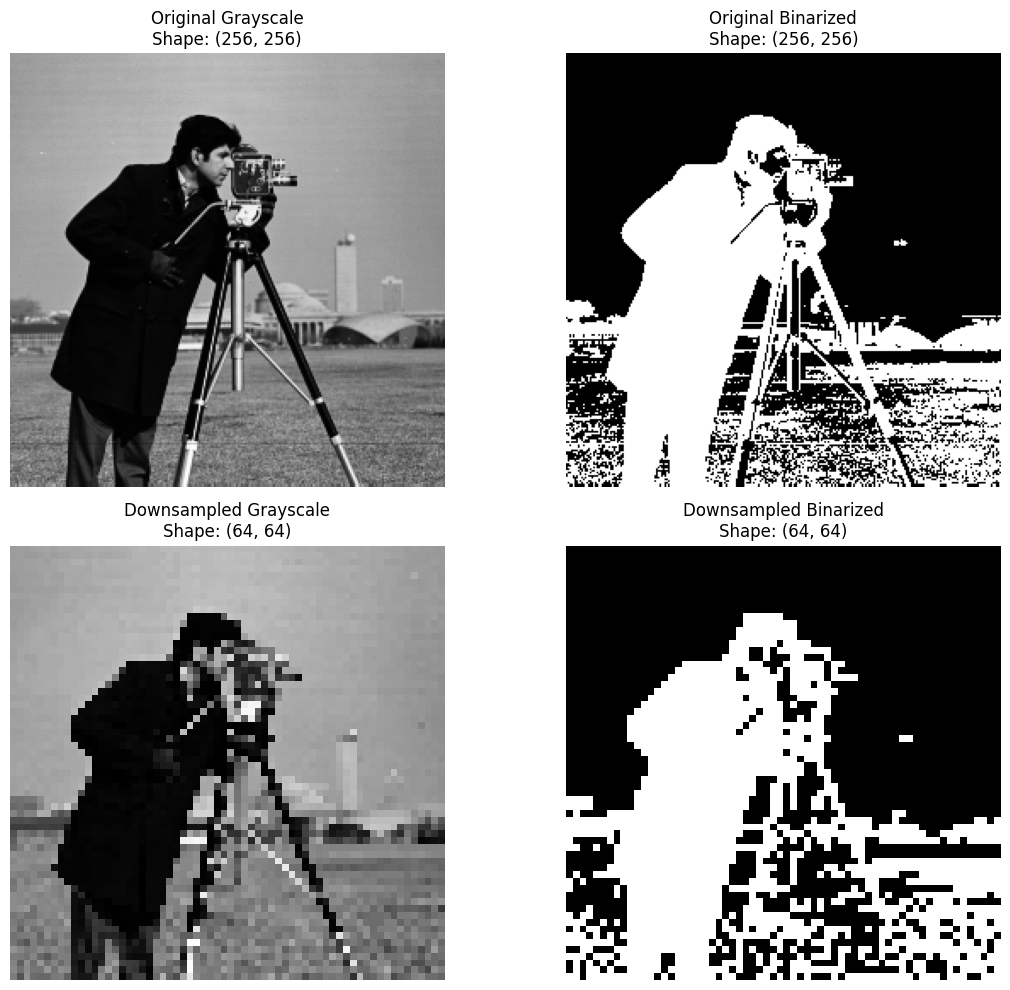

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read the image in grayscale
img_path = 'cameraman.png' 
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Create a dummy image in case the path isn't found
if img is None:
    print("Image not found, generating a test image with shapes...")
    img = np.zeros((200, 200), dtype=np.uint8)
    img[50:150, 50:150] = 255  # Square
    img[80:120, 80:120] = 0    # Hole in square
    cv2.circle(img, (150, 50), 30, 255, -1) # Circle

# 2. Binarize the original image
_, binary_orig = cv2.threshold(img, 127, 1, cv2.THRESH_BINARY_INV)
    
# 3. Create the downsampled version and binarize it
downsample_factor = 4
img_downsampled = img[::downsample_factor, ::downsample_factor]
_, binary_down = cv2.threshold(img_downsampled, 127, 1, cv2.THRESH_BINARY_INV)

# --- VISUALIZE PREPROCESSING STEPS ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title(f'Original Grayscale\nShape: {img.shape}')
axes[0, 0].axis('off')

axes[0, 1].imshow(binary_orig, cmap='gray')
axes[0, 1].set_title(f'Original Binarized\nShape: {binary_orig.shape}')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_downsampled, cmap='gray')
axes[1, 0].set_title(f'Downsampled Grayscale\nShape: {img_downsampled.shape}')
axes[1, 0].axis('off')

axes[1, 1].imshow(binary_down, cmap='gray')
axes[1, 1].set_title(f'Downsampled Binarized\nShape: {binary_down.shape}')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

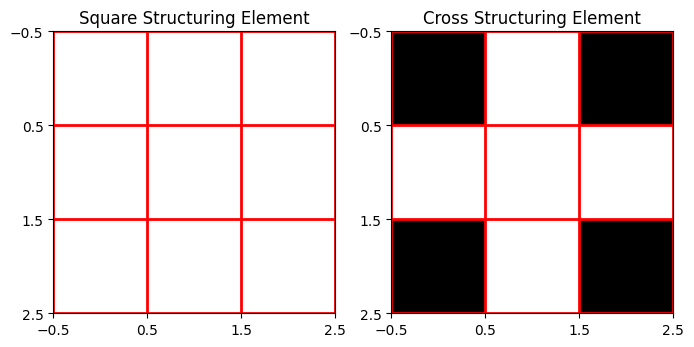

In [17]:
# Define 3x3 Square Kernel
kernel_square = np.ones((3, 3), dtype=np.uint8)

# Define 3x3 Cross-shaped Kernel
kernel_cross = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=np.uint8)

# --- VISUALIZE KERNELS ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(kernel_square, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Square Structuring Element')
axes[0].set_xticks(np.arange(-0.5, 3, 1))
axes[0].set_yticks(np.arange(-0.5, 3, 1))
axes[0].grid(color='red', linewidth=2)

axes[1].imshow(kernel_cross, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Cross Structuring Element')
axes[1].set_xticks(np.arange(-0.5, 3, 1))
axes[1].set_yticks(np.arange(-0.5, 3, 1))
axes[1].grid(color='red', linewidth=2)

plt.show()

In [18]:
def apply_erosion(image, kernel):
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2
    
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=1)
    output_img = np.zeros_like(image)
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_img[i:i+k_h, j:j+k_w]
            output_img[i, j] = np.min(region[kernel == 1])
            
    return output_img

def apply_dilation(image, kernel):
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2
    
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    output_img = np.zeros_like(image)
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_img[i:i+k_h, j:j+k_w]
            output_img[i, j] = np.max(region[kernel == 1])
            
    return output_img

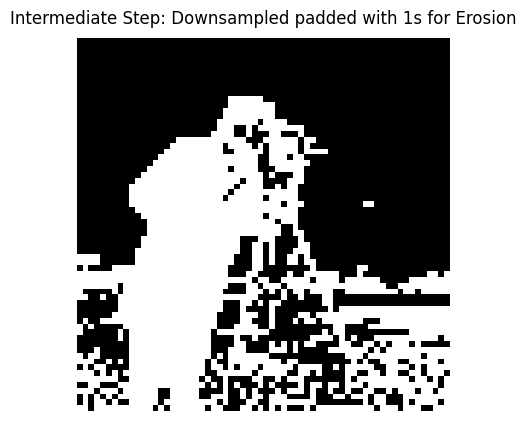

Processing downsampled image...
Processing original image (this may take a moment)...
Done!


In [19]:
# --- VISUALIZE PADDING (Intermediate Step) ---
pad_amount = 1
padded_downsampled = np.pad(binary_down, ((pad_amount, pad_amount), (pad_amount, pad_amount)), mode='constant', constant_values=1)

plt.figure(figsize=(5, 5))
plt.imshow(padded_downsampled, cmap='gray')
plt.title('Intermediate Step: Downsampled padded with 1s for Erosion')
plt.axis('off')
plt.show()

# --- EXECUTE ON DOWNSAMPLED IMAGE ---
print("Processing downsampled image...")
eroded_sq_down = apply_erosion(binary_down, kernel_square)
eroded_cr_down = apply_erosion(binary_down, kernel_cross)
dilated_sq_down = apply_dilation(binary_down, kernel_square)
dilated_cr_down = apply_dilation(binary_down, kernel_cross)

# --- EXECUTE ON ORIGINAL IMAGE ---
print("Processing original image (this may take a moment)...")
eroded_sq_orig = apply_erosion(binary_orig, kernel_square)
eroded_cr_orig = apply_erosion(binary_orig, kernel_cross)
dilated_sq_orig = apply_dilation(binary_orig, kernel_square)
dilated_cr_orig = apply_dilation(binary_orig, kernel_cross)
print("Done!")

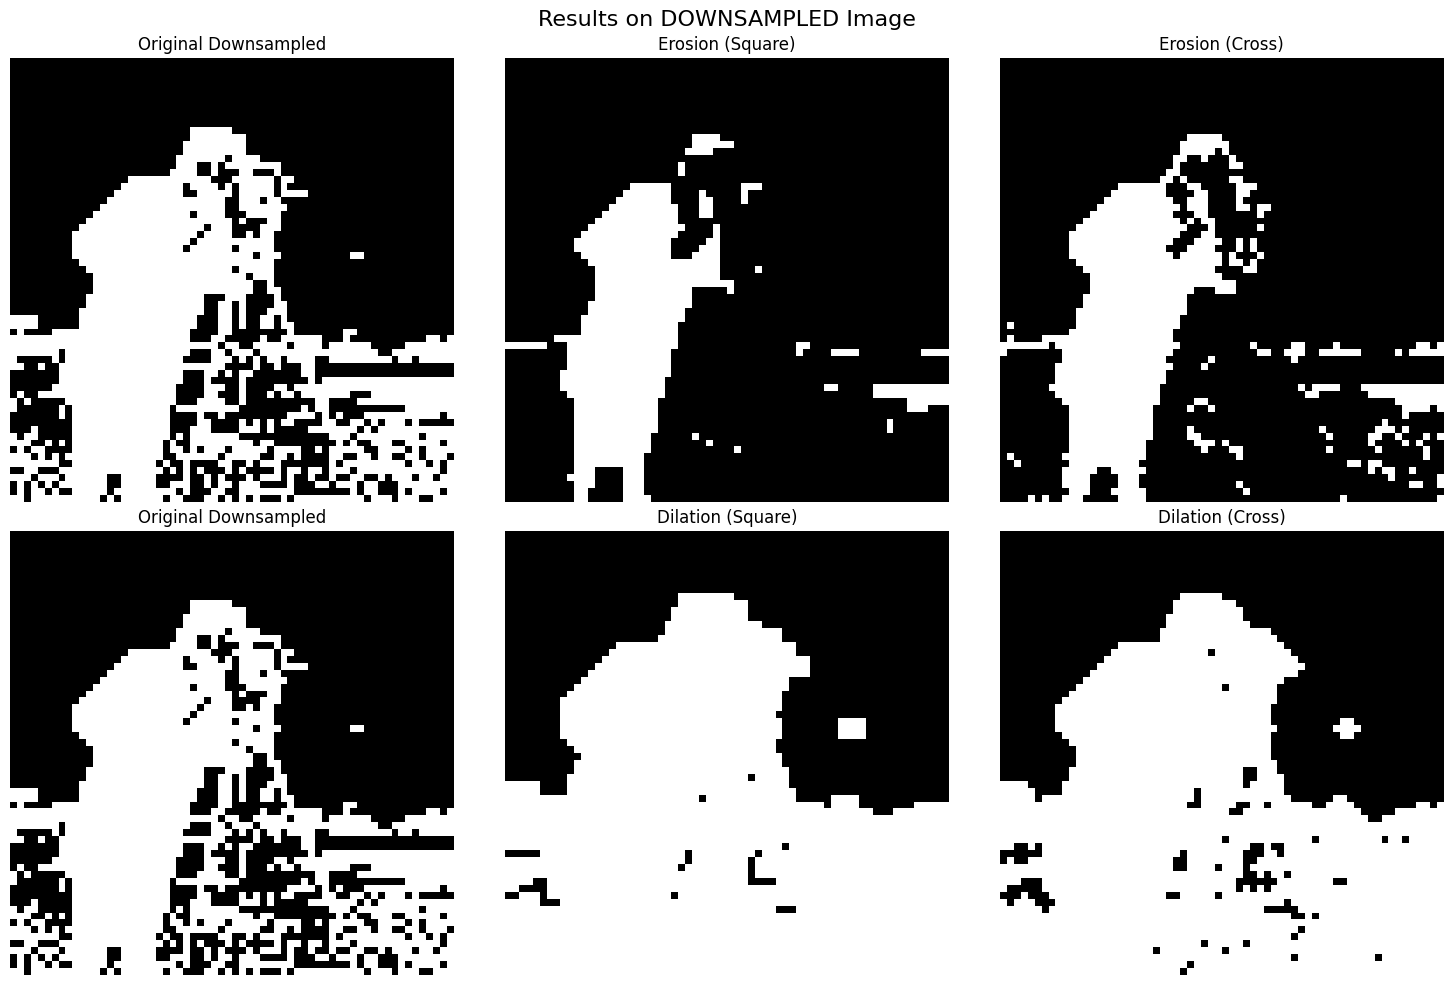

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Results on DOWNSAMPLED Image", fontsize=16)

# Top row: Downsampled Erosion
axes[0, 0].imshow(binary_down, cmap='gray')
axes[0, 0].set_title('Original Downsampled')
axes[0, 0].axis('off')

axes[0, 1].imshow(eroded_sq_down, cmap='gray')
axes[0, 1].set_title('Erosion (Square)')
axes[0, 1].axis('off')

axes[0, 2].imshow(eroded_cr_down, cmap='gray')
axes[0, 2].set_title('Erosion (Cross)')
axes[0, 2].axis('off')

# Bottom row: Downsampled Dilation
axes[1, 0].imshow(binary_down, cmap='gray')
axes[1, 0].set_title('Original Downsampled')
axes[1, 0].axis('off')

axes[1, 1].imshow(dilated_sq_down, cmap='gray')
axes[1, 1].set_title('Dilation (Square)')
axes[1, 1].axis('off')

axes[1, 2].imshow(dilated_cr_down, cmap='gray')
axes[1, 2].set_title('Dilation (Cross)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

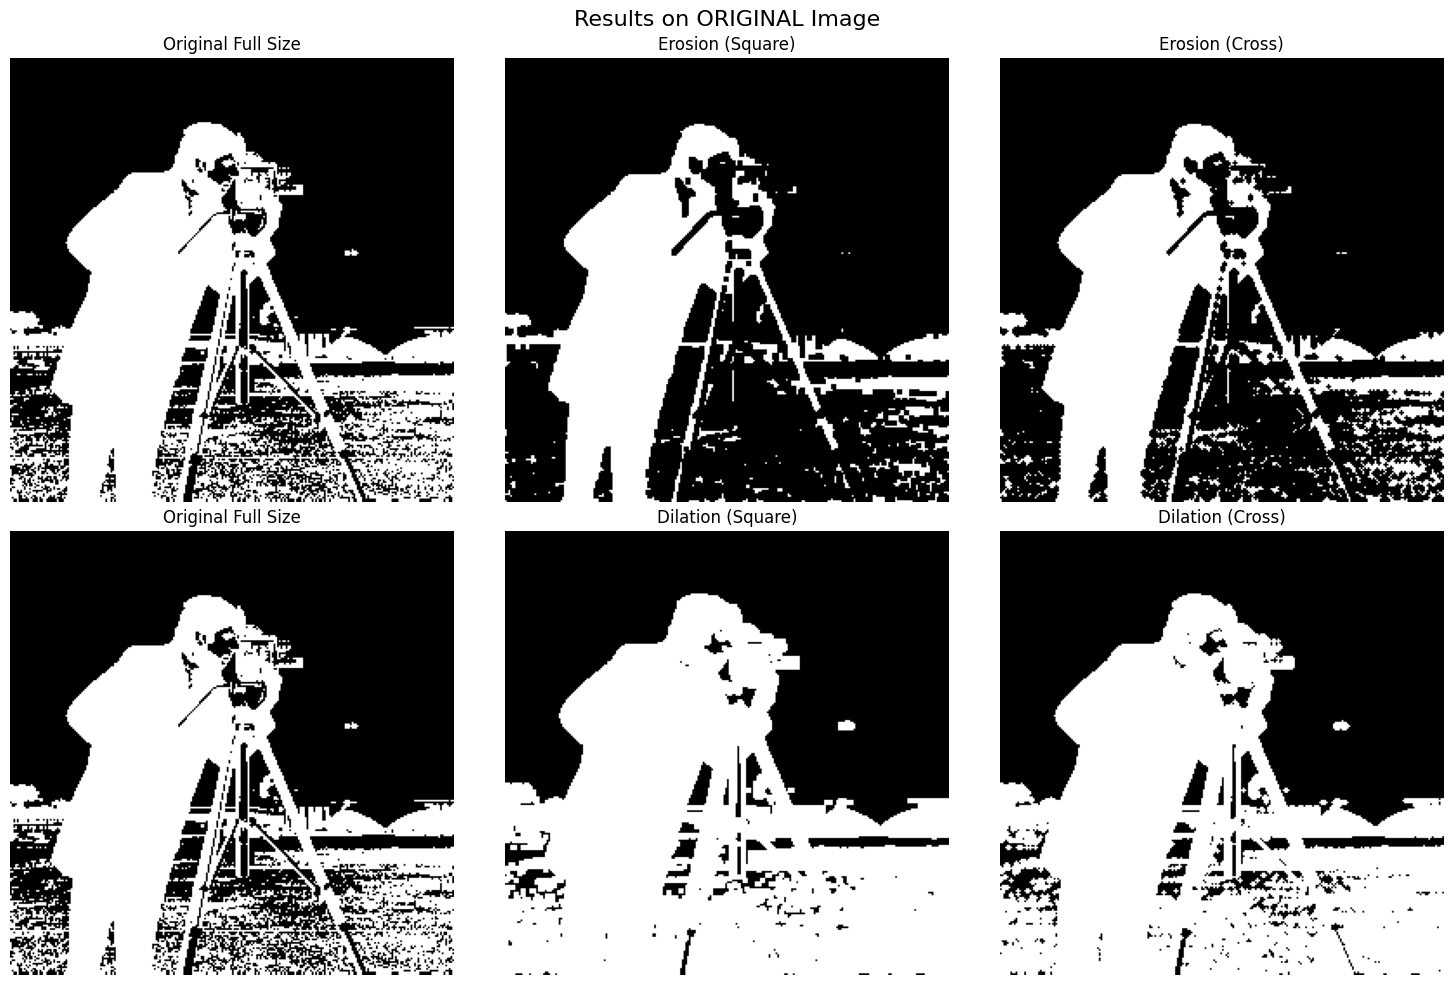

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Results on ORIGINAL Image", fontsize=16)

# Top row: Original Erosion
axes[0, 0].imshow(binary_orig, cmap='gray')
axes[0, 0].set_title('Original Full Size')
axes[0, 0].axis('off')

axes[0, 1].imshow(eroded_sq_orig, cmap='gray')
axes[0, 1].set_title('Erosion (Square)')
axes[0, 1].axis('off')

axes[0, 2].imshow(eroded_cr_orig, cmap='gray')
axes[0, 2].set_title('Erosion (Cross)')
axes[0, 2].axis('off')

# Bottom row: Original Dilation
axes[1, 0].imshow(binary_orig, cmap='gray')
axes[1, 0].set_title('Original Full Size')
axes[1, 0].axis('off')

axes[1, 1].imshow(dilated_sq_orig, cmap='gray')
axes[1, 1].set_title('Dilation (Square)')
axes[1, 1].axis('off')

axes[1, 2].imshow(dilated_cr_orig, cmap='gray')
axes[1, 2].set_title('Dilation (Cross)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [23]:
# --- 1. CALCULATE MATHEMATICAL PARAMETERS (AREA) ---
# Summing the 1s gives us the exact pixel count (area) of the subject
area_orig = np.sum(binary_down)

area_eroded_sq = np.sum(eroded_sq_down)
area_eroded_cr = np.sum(eroded_cr_down)

area_dilated_sq = np.sum(dilated_sq_down)
area_dilated_cr = np.sum(dilated_cr_down)

print("--- AREA COMPARISONS (Downsampled Image) ---")
print(f"Original Subject Area: {area_orig} pixels\n")

print("EROSION (Shrinking):")
print(f" - Square Kernel Area: {area_eroded_sq} pixels (Lost {area_orig - area_eroded_sq} pixels)")
print(f" - Cross Kernel Area:  {area_eroded_cr} pixels (Lost {area_orig - area_eroded_cr} pixels)")
print(f"   *Notice the square kernel removes more area than the cross kernel.\n")

print("DILATION (Expanding):")
print(f" - Square Kernel Area: {area_dilated_sq} pixels (Gained {area_dilated_sq - area_orig} pixels)")
print(f" - Cross Kernel Area:  {area_dilated_cr} pixels (Gained {area_dilated_cr - area_orig} pixels)")



--- AREA COMPARISONS (Downsampled Image) ---
Original Subject Area: 1613 pixels

EROSION (Shrinking):
 - Square Kernel Area: 676 pixels (Lost 937 pixels)
 - Cross Kernel Area:  855 pixels (Lost 758 pixels)
   *Notice the square kernel removes more area than the cross kernel.

DILATION (Expanding):
 - Square Kernel Area: 2385 pixels (Gained 772 pixels)
 - Cross Kernel Area:  2268 pixels (Gained 655 pixels)
